In [23]:
import os
import pandas as pd
import matplotlib.pyplot as plt

# Excel-Datei
datei = "/Users/sascha0404/Documents/UNI/Chemie/5. Semester/PR Instrumentalanalytisches Praktikum/HPLC/Chromatogramme_Gruppe_3.xlsx"

# Ausgabeordner
ausgabe_ordner = "/Users/sascha0404/Documents/UNI/Chemie/5. Semester/PR Instrumentalanalytisches Praktikum/HPLC/Plots"
os.makedirs(ausgabe_ordner, exist_ok=True)

# Alle Sheets laden
alle_sheets = pd.read_excel(datei, sheet_name=None)

for name, df in alle_sheets.items():
    print("Verarbeite:", name)

    # Spaltennamen säubern
    df.columns = [str(c).strip() for c in df.columns]

    try:
        x = df["Retentionszeit /min"]
        y = df["Intensität /mAU"]
    except KeyError:
        print("⚠ Spalten fehlen – übersprungen")
        print("   Gefundene Spalten:", df.columns.tolist())
        continue

    daten = pd.DataFrame({"t": x, "I": y}).dropna()
    t = daten["t"].values
    I = daten["I"].values

    # ---------- PEAKS FINDEN ----------
    peaks, props = find_peaks(
        I,
        prominence=0.98 * I.max(),
        distance=40
    )

    print(f"  Gefundene relevante Peaks: {len(peaks)}")

    # ---------- PLOT ----------
    fig, ax = plt.subplots()
    ax.plot(t, I, linewidth=1)
    ax.set_xlabel("Retentionszeit [min]")
    ax.set_ylabel("Intensität [mAU]")
  # Titel anpassen: ppm → mg/L (nur für Standards)
    titel_name = name.replace("ppm", "mg/L")

    ax.set_title(f"Chromatogramm – {titel_name}")
    ax.grid(True)

    # Y-Achse etwas höher
    y_min = I.min()
    y_max = I.max()
    ax.set_ylim(y_min - 0.05 * abs(y_min),
                y_max + 0.35 * y_max)

 # ---------- PEAKS BESCHRIFTEN ----------
    for nr, idx in enumerate(peaks, start=1):
        t_peak = t[idx]
        I_peak = I[idx]

        ax.plot(t_peak, I_peak, "ro", markersize=4)
        ax.text(
            t_peak,
            I_peak,
            f"Peak {nr}\n{t_peak:.2f} min",
            rotation=90,
            va="bottom",
            ha="center",
            fontsize=8
        )

    fig.tight_layout()

    # ---------- HIER SPEICHERN ----------
    png_name = f"Chromatogramm_{name}.png".replace(" ", "_")
    png_pfad = os.path.join(ausgabe_ordner, png_name)
    fig.savefig(png_pfad, dpi=300)
    plt.close(fig)

    print("✅ Gespeichert:", png_pfad)

Verarbeite: Std_Mix_30ppm
  Gefundene relevante Peaks: 1
✅ Gespeichert: /Users/sascha0404/Documents/UNI/Chemie/5. Semester/PR Instrumentalanalytisches Praktikum/HPLC/Plots/Chromatogramm_Std_Mix_30ppm.png
Verarbeite: Naproxen
  Gefundene relevante Peaks: 1
✅ Gespeichert: /Users/sascha0404/Documents/UNI/Chemie/5. Semester/PR Instrumentalanalytisches Praktikum/HPLC/Plots/Chromatogramm_Naproxen.png
Verarbeite: Ibuprofen
  Gefundene relevante Peaks: 1
✅ Gespeichert: /Users/sascha0404/Documents/UNI/Chemie/5. Semester/PR Instrumentalanalytisches Praktikum/HPLC/Plots/Chromatogramm_Ibuprofen.png
Verarbeite: Diclofenac
  Gefundene relevante Peaks: 1
✅ Gespeichert: /Users/sascha0404/Documents/UNI/Chemie/5. Semester/PR Instrumentalanalytisches Praktikum/HPLC/Plots/Chromatogramm_Diclofenac.png
Verarbeite: Carbamazepin
  Gefundene relevante Peaks: 1
✅ Gespeichert: /Users/sascha0404/Documents/UNI/Chemie/5. Semester/PR Instrumentalanalytisches Praktikum/HPLC/Plots/Chromatogramm_Carbamazepin.png
Verarb

Verarbeite: Std_Mix_30ppm
  Gefundene relevante Peaks: 5
Verarbeite: Naproxen
  Gefundene relevante Peaks: 1
Verarbeite: Ibuprofen
  Gefundene relevante Peaks: 5
Verarbeite: Diclofenac
  Gefundene relevante Peaks: 3
Verarbeite: Carbamazepin
  Gefundene relevante Peaks: 1
Verarbeite: Estradiol
  Gefundene relevante Peaks: 9
✅ Gespeichert: /Users/sascha0404/Documents/UNI/Chemie/5. Semester/PR Instrumentalanalytisches Praktikum/HPLC/Plots/Chromatogramm_Estradiol.png
k_Carbamzepin = 0.4592511013215858
k_Ibuprofen = 2.5352422907488985
k_Diclofenac = 2.182819383259912
k_Naproxen = 0.9493392070484581
k_Estradiol = 1.252202643171806


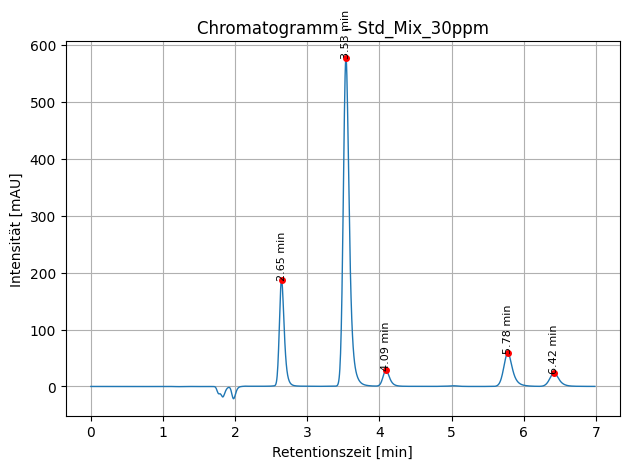

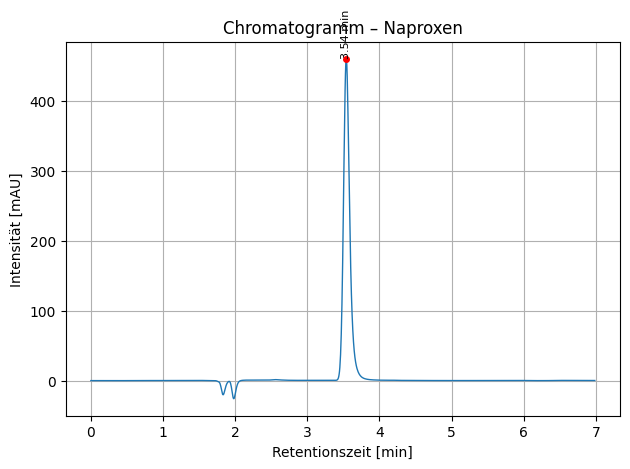

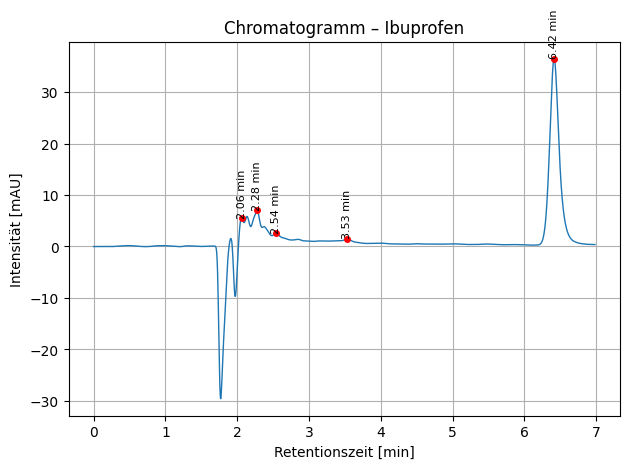

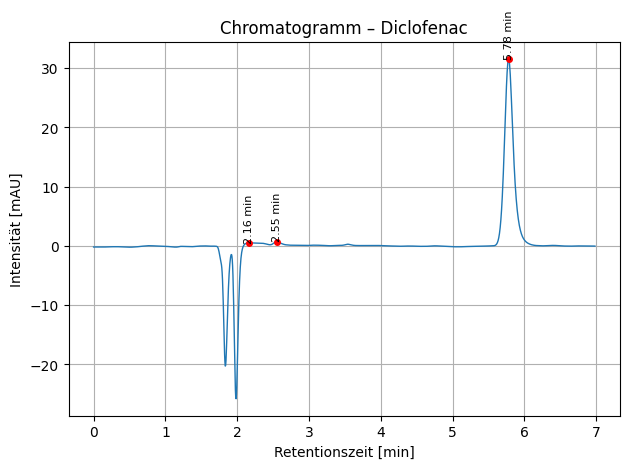

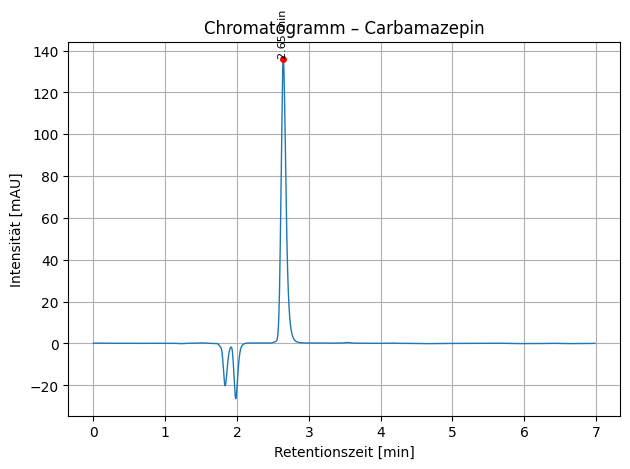

In [6]:
import os
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import find_peaks

# Excel-Datei
datei = "/Users/sascha0404/Documents/UNI/Chemie/5. Semester/PR Instrumentalanalytisches Praktikum/HPLC/Chromatogramme_Gruppe_3.xlsx"

# Ausgabeordner
ausgabe_ordner = "/Users/sascha0404/Documents/UNI/Chemie/5. Semester/PR Instrumentalanalytisches Praktikum/HPLC/Plots"
os.makedirs(ausgabe_ordner, exist_ok=True)

# Alle Sheets laden
alle_sheets = pd.read_excel(datei, sheet_name=None)

for name, df in alle_sheets.items():
    print("Verarbeite:", name)

    # Spaltennamen säubern
    df.columns = [str(c).strip() for c in df.columns]

    try:
        x = df["Retentionszeit /min"]
        y = df["Intensität /mAU"]
    except KeyError:
        print("⚠ Spalten fehlen – übersprungen")
        print("   Gefundene Spalten:", df.columns.tolist())
        continue

    daten = pd.DataFrame({"t": x, "I": y}).dropna()

    t = daten["t"].values
    I = daten["I"].values

    # ---------- NUR RELEVANTE PEAKS FINDEN ----------
    peaks, props = find_peaks(
        I,
        height=0.0 * I.max(),     # nur Peaks > 20 % vom Maximum
        prominence=0.01 * I.max(), # nur deutlich hervortretende Peaks
        distance=40                # Mindestabstand in Punkten
    )

    print(f"  Gefundene relevante Peaks: {len(peaks)}")

    # ---------- PLOT ----------
    fig, ax = plt.subplots()

    ax.plot(t, I, linewidth=1)
    ax.set_xlabel("Retentionszeit [min]")
    ax.set_ylabel("Intensität [mAU]")
    ax.set_title(f"Chromatogramm – {name}")
    ax.grid(True)

    # ---------- PEAKS EINZEICHNEN + t_R BESCHRIFTEN ----------
    for idx in peaks:
        t_peak = t[idx]
        I_peak = I[idx]

        # Punkt am Peak
        ax.plot(t_peak, I_peak, "ro", markersize=4)

        # Retentionszeit als Text
        ax.text(
            t_peak,
            I_peak,
            f"{t_peak:.2f} min",
            rotation=90,
            va="bottom",
            ha="center",
            fontsize=8
        )

    fig.tight_layout()

#Kapazitätsfaktor von Carbamzepin
t_M = 1.816
k_Carbamzepin = (2.65 - t_M) / t_M

#Kapazitätsfaktor von Ibuprofen
t_M = 1.816
k_Ibuprofen= (6.42 - t_M) / t_M

#Kapazitätsfaktor von Diclofenac
t_M = 1.816
k_Diclofenac = (5.78 - t_M) / t_M

#Kapazitätsfaktor von Naproxen
t_M = 1.816
k_Naproxen = (3.54 - t_M) / t_M

#Kapazitätsfaktor von Estradiol
t_M = 1.816
k_Estradiol = (4.09 - t_M) / t_M

# ---------- SPEICHERN ----------
png_name = f"Chromatogramm_{name}.png".replace(" ", "_")
png_pfad = os.path.join(ausgabe_ordner, png_name)
fig.savefig(png_pfad, dpi=300)
plt.close(fig)

print("✅ Gespeichert:", png_pfad)

print("k_Carbamzepin =", k_Carbamzepin)
print("k_Ibuprofen =", k_Ibuprofen)
print("k_Diclofenac =", k_Diclofenac)
print("k_Naproxen =", k_Naproxen)
print("k_Estradiol =", k_Estradiol)


In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import find_peaks
from scipy.optimize import curve_fit   # <--- WICHTIG!

# Excel-Datei
datei = "/Users/sascha0404/Documents/UNI/Chemie/5. Semester/PR Instrumentalanalytisches Praktikum/HPLC/Chromatogramme_Gruppe_3.xlsx"

# Ausgabeordner
ausgabe_ordner = "/Users/sascha0404/Documents/UNI/Chemie/5. Semester/PR Instrumentalanalytisches Praktikum/HPLC/Plots"
os.makedirs(ausgabe_ordner, exist_ok=True)

# ✅ NUR SHEET 1 LADEN
sheet_name = "Sheet_1"
df = pd.read_excel(datei, sheet_name=0)

print("Verarbeite:", sheet_name)

# Spaltennamen säubern
df.columns = [str(c).strip() for c in df.columns]

t = df["Retentionszeit /min"].dropna().values
I = df["Intensität /mAU"].dropna().values

# ---------- ALLE POSITIVEN PEAKS FINDEN ----------
peaks_all, _ = find_peaks(
    I,
    prominence=0.02 * np.max(I),   # nicht nur Rauschen
    distance=40                   # genügend Abstand
)

print("Alle gefundenen Peaks:", len(peaks_all))

# ---------- NUR DIE 5 GRÖSSTEN PEAKS BEHALTEN ----------
peaks_sorted = sorted(peaks_all, key=lambda idx: I[idx], reverse=True)
anzahl_peaks = 5
peaks = np.sort(peaks_sorted[:anzahl_peaks])

print("Verwendete Peaks (Top 5):", peaks)

# ---------- ERSTER PLOT: Chromatogramm + Peaknummern ----------
fig1, ax1 = plt.subplots()

ax1.plot(t, I, linewidth=1)
ax1.set_xlabel("Retentionszeit [min]")
ax1.set_ylabel("Intensität [mAU]")
ax1.set_title(f"Chromatogramm – {sheet_name}")
ax1.grid(True)

# Y-Achse etwas anheben
y_min = np.min(I)
y_max = np.max(I)
ax1.set_ylim(y_min - 0.05 * abs(y_min),
             y_max + 0.20 * y_max)

# Peaks beschriften
for i, idx in enumerate(peaks, start=1):
    t_peak = t[idx]
    I_peak = I[idx]

    ax1.plot(t_peak, I_peak, "ro", markersize=3)
    ax1.text(
        t_peak,
        I_peak,
        f"Peak {i}\n{t_peak:.2f} min",
        rotation=90,
        va="bottom",
        ha="center",
        fontsize=8
    )

fig1.tight_layout()

# ---------- SPEICHERN: erster Plot ----------
png_name = f"Chromatogramm_{sheet_name}.png"
png_pfad = os.path.join(ausgabe_ordner, png_name)
fig1.savefig(png_pfad, dpi=300)
plt.close(fig1)

print("✅ Gespeichert:", png_pfad)

# Säulenlänge L (in m oder cm – je nach gewünschter Einheit für H)
L = 0.150  # 15 cm Säule -> 0.150 m

# -------------------------------------------------
# Kapazitätsfaktor k berechnen (manuell vorgegeben)
# k = (t_R - t_M) / t_M
# -------------------------------------------------
t_M = 1.816

k_Peak1 = (2.65 - t_M) / t_M
k_Peak2 = (3.53 - t_M) / t_M
k_Peak3 = (4.09 - t_M) / t_M
k_Peak4 = (5.78 - t_M) / t_M
k_Peak5 = (6.42 - t_M) / t_M

print("Kapazitätsfaktor vom Mix")
print("k_Peak1 =", k_Peak1)
print("k_Peak2 =", k_Peak2)
print("k_Peak3 =", k_Peak3)
print("k_Peak4 =", k_Peak4)
print("k_Peak5 =", k_Peak5)

# ================================================
#   GAUSS-FUNKTION & FIT-FUNKTION
# ================================================
def gauss(t, A, mu, sigma, baseline):
    return A * np.exp(-(t - mu)**2 / (2 * sigma**2)) + baseline


def fit_gaussian_peak(t, I, peak_idx, window_points=80):
    """
    Führt einen Gauß-Fit um einen Peak herum aus.
    Gibt zurück: mu, sigma, A, baseline
    """
    # Fenster um den Peak definieren (Index-basiert)
    i_min = max(0, peak_idx - window_points)
    i_max = min(len(t), peak_idx + window_points)

    t_win = t[i_min:i_max]
    I_win = I[i_min:i_max]

    # Startwerte für den Fit
    A0 = I[peak_idx] - np.min(I_win)
    mu0 = t[peak_idx]
    sigma0 = (t_win[-1] - t_win[0]) / 6  # grobe Schätzung: ±3σ ~ Fenster
    baseline0 = np.min(I_win)

    p0 = [A0, mu0, sigma0, baseline0]

    try:
        popt, pcov = curve_fit(gauss, t_win, I_win, p0=p0, maxfev=10000)
        A, mu, sigma, baseline = popt
        return mu, sigma, A, baseline
    except Exception as e:
        print(f"Warnung: Gauß-Fit für Peak-Index {peak_idx} fehlgeschlagen ({e})")
        return None, None, None, None


# ================================================
#      PEAKS AUSWERTEN – HALBWERTSBREITE w_0,5
# ================================================
print("\n=== Halbwertsbreiten nach Gaussian-Fit (w_0,5 = FWHM) und Plattenzahl N ===")

results = []

for nr, p in enumerate(peaks, start=1):
    mu, sigma, A, baseline = fit_gaussian_peak(t, I, p)

    if mu is None:
        continue

    # Halbwertsbreite (FWHM, w_0,5)
    w_half = 2 * np.sqrt(2 * np.log(2)) * sigma  # in min

    # Grenzen auf halber Höhe
    t_L = mu - w_half / 2
    t_R = mu + w_half / 2

    # Retentionszeit t_R ≙ Peakzentrum mu
    t_R_peak = mu

    # Plattenzahl N nach N = 5,54 * (t_R / w_0,5)^2
    N = 5.54 * (t_R_peak / w_half)**2

    # Bodenhöhe H = L / N
    H = L / N

    # 👉 NEU: Basispeakbreite w_b = 4σ
    w_b = 4 * sigma

    # Index nahe mu für Plot
    idx_mu = np.argmin(np.abs(t - mu))

    # alles speichern (inkl. N, H, w_b)
    results.append((nr, t_L, mu, t_R, w_half, idx_mu, N, H, w_b))

    # Ausgabe im Terminal
    print("-" * 60)
    print(f"Peak {nr}:")
    print(f"   t_R     = {t_R_peak:.4f} min (Peakzentrum μ)")
    print(f"   σ       = {sigma:.4f} min")
    print(f"   w_0,5   = {w_half:.4f} min (FWHM)")
    print(f"   w_b     = {w_b:.4f} min (Basisbreite, 4σ)")
    print(f"   N       = {N:.0f}")
    print(f"   H       = {H:.6f} (Einheit = L/N)")
    print(f"   t_L(0,5)= {t_L:.4f} min  (μ - w_0,5/2)")
    print(f"   t_R(0,5)= {t_R:.4f} min  (μ + w_0,5/2)\n")

    print("\n=== Auflösung R zwischen benachbarten Peaks (Basisbreite w_b) ===")

R_values = []

for i in range(len(results) - 1):
    nr_A, t_LA, mu_A, t_RA, w_halfA, idxA, N_A, H_A, w_bA = results[i]
    nr_B, t_LB, mu_B, t_RB, w_halfB, idxB, N_B, H_B, w_bB = results[i + 1]

    tR_A = mu_A
    tR_B = mu_B

    R = 2 * ((tR_B - tR_A) / (w_bA + w_bB))
    R_values.append((nr_A, nr_B, R))

    print(f"R(Peak {nr_A} – Peak {nr_B}) = {R:.6f}")
    print(f"  tR_A = {tR_A:.6f} min, tR_B = {tR_B:.6f} min")
    print(f"  w_bA = {w_bA:.6f} min, w_bB = {w_bB:.6f} min\n")

# ================================================
#      ZWEITER PLOT: HALBWERTSBREITEN
# ================================================
fig2, ax2 = plt.subplots(figsize=(10, 5))
ax2.plot(t, I, linewidth=1)
ax2.set_xlabel("Retentionszeit [min]")
ax2.set_ylabel("Intensität [mAU]")
ax2.set_title("Chromatogramm Sheet 1 – Halbwertsbreite w₀,₅ (Gaussian-Fit)")
ax2.grid(True)

# Y-Achse etwas nach oben erweitern
y_min = np.min(I)
y_max = np.max(I)

ax2.set_ylim(
    y_min - 0.05 * abs(y_min),   # unten etwas Luft
    y_max + 0.30 * y_max         # oben mehr Platz (30 %)
)

for nr, t_L, mu, t_R, w_half, idx_mu, N, H, w_b in results:
    ax2.plot(t[idx_mu], I[idx_mu], "ro")
    ax2.axvline(t_L, color="green", linestyle="--", linewidth=0.8)
    ax2.axvline(t_R, color="green", linestyle="--", linewidth=0.8)

    ax2.text(
        t[idx_mu],
        I[idx_mu],
        f"Peak {nr}\nμ={mu:.3f} min\nw₀,₅={w_half:.3f} min\nN={N:.0f}\nH={H:.6f}",
        ha="center",
        va="bottom",
        fontsize=7,
    )
fig2.tight_layout()

# optional auch speichern:
fwhm_png = os.path.join(ausgabe_ordner, f"Chromatogramm_FWHM_{sheet_name}.png")
fig2.savefig(fwhm_png, dpi=300)
plt.close(fig2)

print("✅ Gespeichert (FWHM-Plot):", fwhm_png)

Verarbeite: Sheet_1
Alle gefundenen Peaks: 6
Verwendete Peaks (Top 5): [ 545  728  843 1191 1323]
✅ Gespeichert: /Users/sascha0404/Documents/UNI/Chemie/5. Semester/PR Instrumentalanalytisches Praktikum/HPLC/Plots/Chromatogramm_Sheet_1.png
Kapazitätsfaktor vom Mix
k_Peak1 = 0.4592511013215858
k_Peak2 = 0.9438325991189426
k_Peak3 = 1.252202643171806
k_Peak4 = 2.182819383259912
k_Peak5 = 2.5352422907488985

=== Halbwertsbreiten nach Gaussian-Fit (w_0,5 = FWHM) und Plattenzahl N ===
------------------------------------------------------------
Peak 1:
   t_R     = 2.6461 min (Peakzentrum μ)
   σ       = 0.0321 min
   w_0,5   = 0.0755 min (FWHM)
   w_b     = 0.1283 min (Basisbreite, 4σ)
   N       = 6802
   H       = 0.000022 (Einheit = L/N)
   t_L(0,5)= 2.6084 min  (μ - w_0,5/2)
   t_R(0,5)= 2.6839 min  (μ + w_0,5/2)


=== Auflösung R zwischen benachbarten Peaks (Basisbreite w_b) ===
------------------------------------------------------------
Peak 2:
   t_R     = 3.5393 min (Peakzentrum μ)

In [86]:
import pandas as pd

# results = [(nr, t_L, mu, t_R, w_half, idx_mu, N), ...]

df_results = pd.DataFrame(results, columns=[
    "Peak",
    "t_L (min)",
    "mu = t_R (min)",
    "t_R (min)",
    "w_0.5 (min)",
    "idx_mu",
    "N",
    "H",
    "w_b (min)"     # <-- diese Zeile ergänzen
])

df_R = pd.DataFrame(R_values, columns=[
    "Peak A",
    "Peak B",
    "R"
])

output_path = "/Users/sascha0404/Documents/UNI/Chemie/5. Semester/PR Instrumentalanalytisches Praktikum/HPLC/Notizen2.xlsx"

with pd.ExcelWriter(output_path) as writer:
    df_results.to_excel(writer, sheet_name="Peaks", index=False)
    df_R.to_excel(writer, sheet_name="Peaks", index=False)

print("✔ Daten gespeichert in:", output_path)

✔ Daten gespeichert in: /Users/sascha0404/Documents/UNI/Chemie/5. Semester/PR Instrumentalanalytisches Praktikum/HPLC/Notizen2.xlsx
